Imports

In [1]:
import sys

# Tell Jupyter to look in the parent directory
sys.path.append("..")

from sklearn.model_selection import train_test_split
from src.preprocess import load_and_clean_data, add_new_features
from src.model import train_model, get_predictions_and_score
import src.plots as plots
import src.config as config

 Cleaning and Preparing Data

In [2]:
from pathlib import Path

# Load raw data and clean it
raw_df = load_and_clean_data()
df = add_new_features(raw_df)

print("Dataset cleaned and features added successfully!")
df.head()

Path(config.PROCESSED_DATA_PATH).parent.mkdir(parents=True, exist_ok=True)


#save clean data using absolute path
df.to_csv(config.PROCESSED_DATA_PATH, index=False)
print("Saved clean dataset successfully to data/processed/cleaned_steel_data.csv!")

Dataset cleaned and features added successfully!
Saved clean dataset successfully to data/processed/cleaned_steel_data.csv!


Exploratory Visualizations

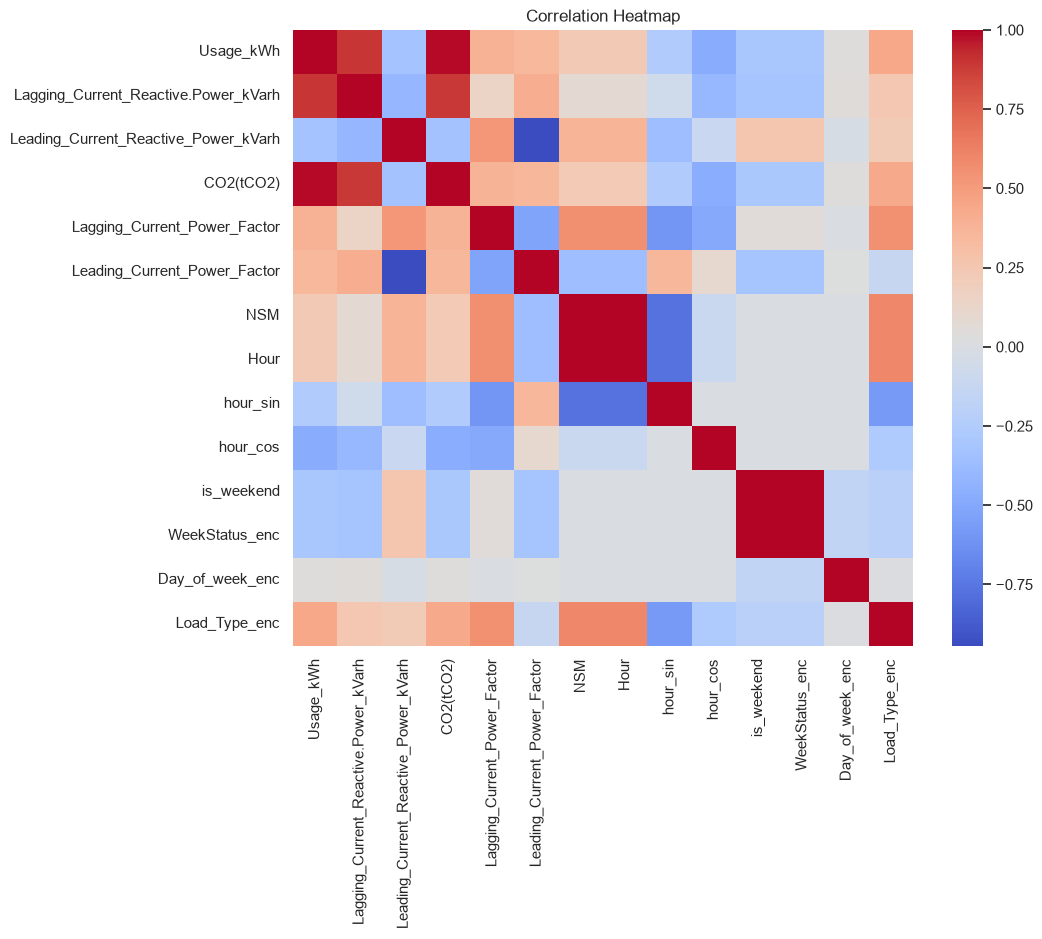

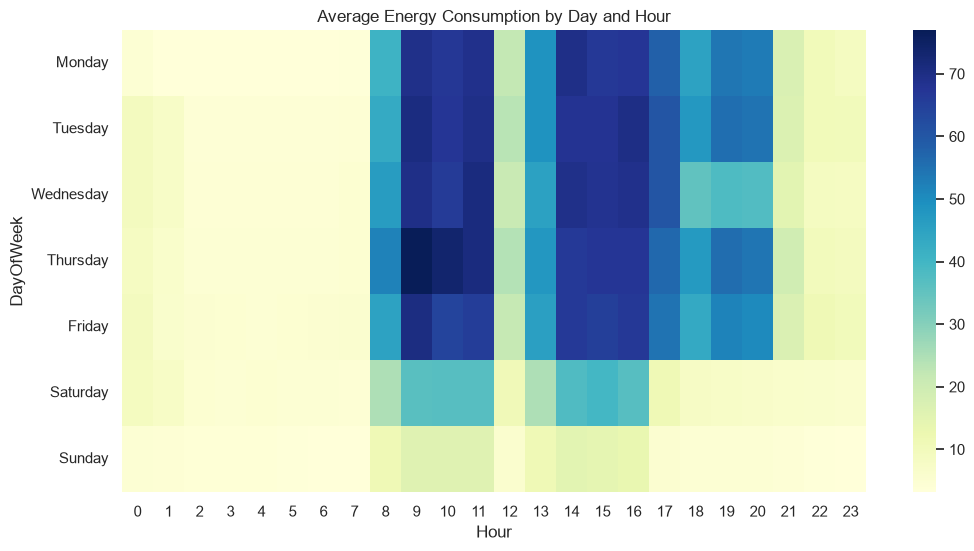

In [3]:
# Plot correlations
plots.plot_correlations(df)

# Plot Day x Hour consumption
plots.plot_weekly_consumption(df)

Train and Evaluate Model

In [4]:
# 1. Select our columns
X = df[config.FEATURES]
y = df[config.TARGET]

# 2. Split into training (80%) and testing (20%) data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the XGBoost model
xgboost_model = train_model("XGBoost", X_train, y_train)

# 4. Predict and evaluate
predictions, r2_score = get_predictions_and_score(xgboost_model, X_test, y_test)
print(f"XGBoost Model R-squared Score: {r2_score:.4f}")

XGBoost Model R-squared Score: 0.9981


Model Charts

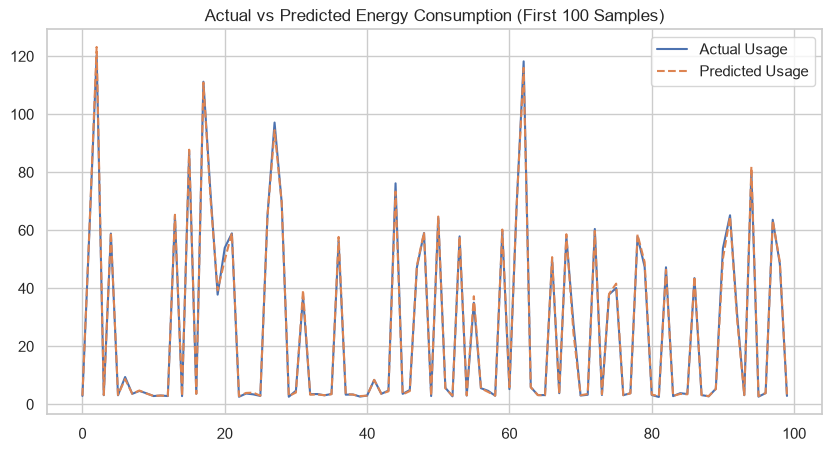

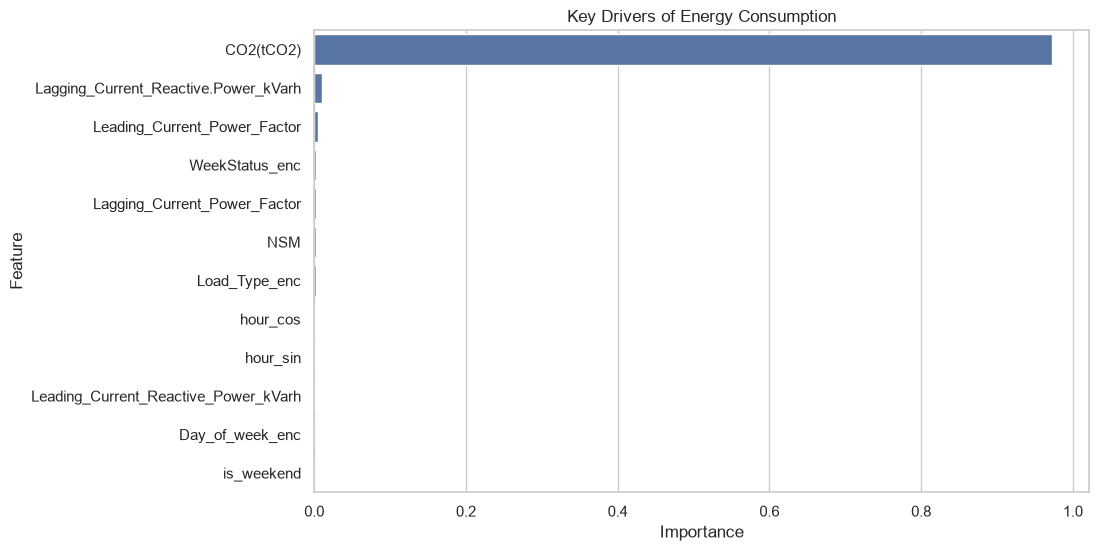

In [5]:
# Compare predictions to actual values
plots.plot_actual_vs_predicted(y_test, predictions)

# See which features are driving the predictions
plots.plot_feature_importance(xgboost_model, config.FEATURES)

Benchmark All Models

In [6]:
models = ["XGBoost", "RandomForest", "LightGBM"]

print(f"{'Model Name':<15} | {'R-squared Score':<15}")
print("-" * 33)

for name in models:
    model = train_model(name, X_train, y_train)
    _, score = get_predictions_and_score(model, X_test, y_test)
    print(f"{name:<15} | {score:.4f}")

Model Name      | R-squared Score
---------------------------------
XGBoost         | 0.9981
RandomForest    | 0.9990
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001668 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1161
[LightGBM] [Info] Number of data points in the train set: 28032, number of used features: 12
[LightGBM] [Info] Start training from score 27.286074
LightGBM        | 0.9976
